In [1]:
""" Libraries configuration for data preprocessing """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder



In [2]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Raw Data\teen_phone_addiction_dataset.csv'
df = pd.read_csv(data)
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


## Data Understanding


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [4]:
df.isna().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [5]:
df.drop(columns=['ID','Name','Location'], inplace=True)

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['Gender', 'School_Grade', 'Phone_Usage_Purpose']


In [7]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numerical_cols)

['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']


**Usage composition**

In [8]:
df['Tracked_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming'] + df['Time_on_Education']
df['Untracked_Hours'] = df['Daily_Usage_Hours'] - df['Tracked_Hours']   # browsing/messaging residual
df['Leisure_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming']
df['Leisure_Ratio'] = df['Leisure_Hours'] / df['Daily_Usage_Hours'].replace(0, np.nan)
df['Education_Ratio'] = df['Time_on_Education'] / df['Daily_Usage_Hours'].replace(0, np.nan)
df['Social_vs_Gaming'] = df['Time_on_Social_Media'] - df['Time_on_Gaming']  # user-type axis

**Weekend/weekday behavior**

In [9]:
df['Weekend_Escalation'] = df['Weekend_Usage_Hours'] - df['Daily_Usage_Hours']
df['Weekend_Ratio'] = df['Weekend_Usage_Hours'] / df['Daily_Usage_Hours'].replace(0, np.nan)

**Intensity / compulsivity**


In [10]:
df['Minutes_Per_Check'] = (df['Daily_Usage_Hours'] * 60) / df['Phone_Checks_Per_Day'].replace(0, np.nan)
df['Checks_Per_App'] = df['Phone_Checks_Per_Day'] / df['Apps_Used_Daily'].replace(0, np.nan)
df['Hours_Per_App'] = df['Daily_Usage_Hours'] / df['Apps_Used_Daily'].replace(0, np.nan)

**Sleep displacement**

In [11]:
df['Sleep_Deficit'] = (9 - df['Sleep_Hours']).clip(lower=0)   # 9h is the teen recommendation, not 8
df['Screen_To_Sleep_Ratio'] = df['Daily_Usage_Hours'] / df['Sleep_Hours'].replace(0, np.nan)
df['Bedtime_Screen_Share'] = df['Screen_Time_Before_Bed'] / df['Daily_Usage_Hours'].replace(0, np.nan)

Offline life displacement

In [12]:
df['Offline_Activity'] = df['Exercise_Hours'] + df['Social_Interactions']
df['Online_To_Offline_Ratio'] = df['Daily_Usage_Hours'] / df['Offline_Activity'].replace(0, np.nan)
df['Family_To_Screen_Ratio'] = df['Family_Communication'] / df['Daily_Usage_Hours'].replace(0, np.nan)

**Psychological composite**

In [13]:
for c in ['Anxiety_Level', 'Depression_Level', 'Self_Esteem']:
    df[f'{c}_z'] = (df[c] - df[c].mean()) / df[c].std()
df['Distress_Index'] = df[['Anxiety_Level_z', 'Depression_Level_z']].mean(axis=1) - df['Self_Esteem_z']

**Context / moderator**

In [14]:
df['Academic_Per_Usage'] = df['Academic_Performance'] / df['Daily_Usage_Hours'].replace(0, np.nan)
df['Unsupervised_Usage'] = df['Daily_Usage_Hours'] * (1 - df['Parental_Control'])  # Parental_Control is 0/1
df['Grade_Num'] = df['School_Grade'].str.extract(r'(\d+)').astype(int)  # ordinal, better than one-hot

In [15]:
raw_col = ['Age',
 'Gender',
 'School_Grade',
 'Daily_Usage_Hours',
 'Sleep_Hours',
 'Academic_Performance',
 'Social_Interactions',
 'Exercise_Hours',
 'Anxiety_Level',
 'Depression_Level',
 'Self_Esteem',
 'Parental_Control',
 'Screen_Time_Before_Bed',
 'Phone_Checks_Per_Day',
 'Apps_Used_Daily',
 'Time_on_Social_Media',
 'Time_on_Gaming',
 'Time_on_Education',
 'Phone_Usage_Purpose',
 'Family_Communication',
 'Weekend_Usage_Hours']

In [16]:
df.drop(columns=raw_col, inplace=True)

In [17]:
df

,Addiction_Level,Tracked_Hours,Untracked_Hours,Leisure_Hours,Leisure_Ratio,Education_Ratio,Social_vs_Gaming,Weekend_Escalation,Weekend_Ratio,Minutes_Per_Check,...,Offline_Activity,Online_To_Offline_Ratio,Family_To_Screen_Ratio,Anxiety_Level_z,Depression_Level_z,Self_Esteem_z,Distress_Index,Academic_Per_Usage,Unsupervised_Usage,Grade_Num
0,10.0,6.5,-2.5,5.3,1.325000,0.300000,1.9,4.7,2.175000,2.790698,...,5.1,0.784314,1.000000,1.525594,-0.856794,0.857699,-0.523299,19.500000,4.0,9
1,10.0,6.9,-1.4,5.1,0.927273,0.327273,-2.9,-0.2,0.963636,3.437500,...,5.0,1.100000,0.363636,-0.895984,0.536178,-0.890092,0.710189,12.727273,5.5,7
2,9.2,2.2,3.6,1.8,0.310345,0.068966,-1.2,-0.1,0.982759,2.540146,...,8.8,0.659091,1.034483,-1.241923,-0.856794,1.556816,-2.606174,16.034483,5.8,11
3,9.8,5.5,-2.4,4.7,1.516129,0.258065,1.5,-0.1,0.967742,1.453125,...,9.6,0.322917,2.580645,1.179654,1.580908,-0.890092,2.270372,25.161290,3.1,12
4,8.6,4.6,-2.1,3.5,1.400000,0.440000,1.7,1.2,1.480000,1.562500,...,5.1,0.490196,4.000000,-1.587863,-0.160308,-1.589208,0.715123,22.400000,2.5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,9.8,5.5,-1.6,4.5,1.153846,0.256410,0.9,5.5,2.410256,2.925000,...,4.9,0.795918,2.051282,0.487775,1.580908,-1.239650,2.273991,13.589744,0.0,12
2996,5.5,3.4,0.2,3.1,0.861111,0.083333,3.1,1.6,1.444444,4.800000,...,5.0,0.720000,2.500000,0.833714,0.884421,1.207257,-0.348189,25.833333,0.0,8
2997,6.2,5.0,-1.8,2.6,0.812500,0.750000,2.2,2.7,1.843750,3.764706,...,1.0,3.200000,2.812500,-0.550044,-0.856794,1.207257,-1.910676,30.625000,3.2,7
2998,10.0,5.8,0.9,4.3,0.641791,0.223881,-0.9,-0.6,0.910448,3.216000,...,3.2,2.093750,0.597015,-0.895984,-0.160308,1.207257,-1.735403,10.000000,6.7,9


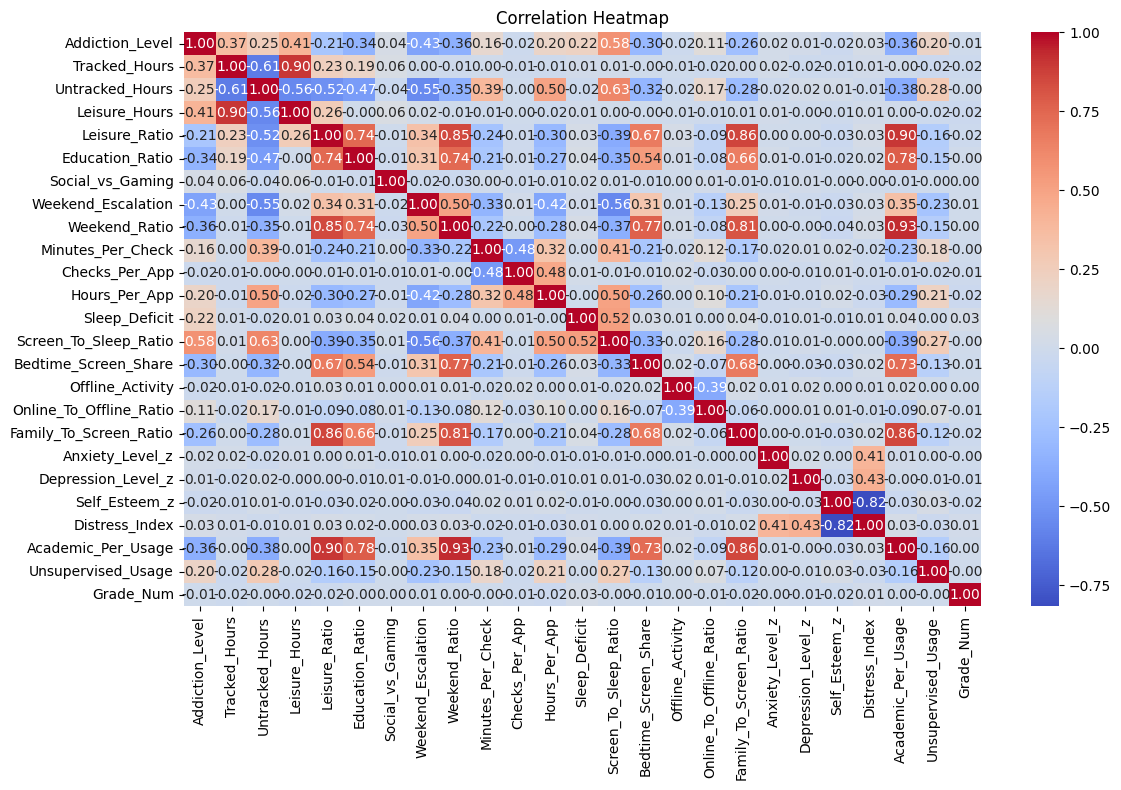

In [18]:
plt.figure(figsize=(12, 8))
plt.title('Correlation Heatmap')
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.tight_layout()
plt.show()

In [19]:
df.isnull().sum()

Addiction_Level             0
Tracked_Hours               0
Untracked_Hours             0
Leisure_Hours               0
Leisure_Ratio              25
Education_Ratio            25
Social_vs_Gaming            0
Weekend_Escalation          0
Weekend_Ratio              25
Minutes_Per_Check           0
Checks_Per_App              0
Hours_Per_App               0
Sleep_Deficit               0
Screen_To_Sleep_Ratio       0
Bedtime_Screen_Share       25
Offline_Activity            0
Online_To_Offline_Ratio    30
Family_To_Screen_Ratio     25
Anxiety_Level_z             0
Depression_Level_z          0
Self_Esteem_z               0
Distress_Index              0
Academic_Per_Usage         25
Unsupervised_Usage          0
Grade_Num                   0
dtype: int64

In [20]:
# df.to_csv('preprocessed_data.csv', index=False)